# Chapter 2 Practical 01: Feature Vectors and Similarity

Learning objectives:
- Represent movies with numeric, categorical, and multi-label features.
- Compute cosine similarity, Jaccard similarity, and Euclidean distance.
- Interpret what each similarity measure means.
- Plot items in a simple 2D feature space.

Slide connection: item representation, feature vectors, vector space, cosine similarity, Jaccard similarity, and Euclidean distance.


We start with five familiar movies and a few hand-written content features. Small examples make the vector idea easier to see.


In [1]:
# Teaching note: Create a tiny movie table so every feature value is easy to inspect.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# Cosine similarity turns vectors into pairwise recommendation scores.
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances
# MultiLabelBinarizer expands genre lists into one binary column per genre.
from sklearn.preprocessing import MultiLabelBinarizer, MinMaxScaler

movies = pd.DataFrame({
    "title": ["Inception", "Interstellar", "Titanic", "The Matrix", "Toy Story"],
    "duration_min": [148, 169, 195, 136, 81],
    "rating": [8.8, 8.7, 7.9, 8.7, 8.3],
    "genres": [
        ["Sci-Fi", "Thriller", "Action"],
        ["Sci-Fi", "Adventure", "Drama"],
        ["Romance", "Drama"],
        ["Sci-Fi", "Action"],
        ["Animation", "Adventure", "Comedy", "Family"],
    ],
})
movies


,title,duration_min,rating,genres
0,Inception,148,8.8,"[Sci-Fi, Thriller, Action]"
1,Interstellar,169,8.7,"[Sci-Fi, Adventure, Drama]"
2,Titanic,195,7.9,"[Romance, Drama]"
3,The Matrix,136,8.7,"[Sci-Fi, Action]"
4,Toy Story,81,8.3,"[Animation, Adventure, Comedy, Family]"


Numeric features need scaling because duration and rating live on different ranges.


In [2]:
# Teaching note: Scale numeric columns so duration and rating contribute on comparable ranges.
# MinMaxScaler puts numeric features on a shared 0-1 scale.
scaler = MinMaxScaler()
numeric_features = pd.DataFrame(
    scaler.fit_transform(movies[["duration_min", "rating"]]),
    columns=["duration_scaled", "rating_scaled"],
    index=movies["title"],
)
numeric_features.round(2)


,duration_scaled,rating_scaled
title,,
Inception,0.59,1.00
Interstellar,0.77,0.89
Titanic,1.00,0.00
The Matrix,0.48,0.89
Toy Story,0.00,0.44


Genres are multi-label categorical features: one movie can belong to several genres. We encode each genre as a 0/1 column.


In [3]:
# Teaching note: Turn multi-label genres into one binary column per genre.
# MultiLabelBinarizer expands genre lists into one binary column per genre.
mlb = MultiLabelBinarizer()
genre_features = pd.DataFrame(
    mlb.fit_transform(movies["genres"]),
    columns=mlb.classes_,
    index=movies["title"],
)
genre_features


,Action,Adventure,Animation,Comedy,Drama,Family,Romance,Sci-Fi,Thriller
title,,,,,,,,,
Inception,1,0,0,0,0,0,0,1,1
Interstellar,0,1,0,0,1,0,0,1,0
Titanic,0,0,0,0,1,0,1,0,0
The Matrix,1,0,0,0,0,0,0,1,0
Toy Story,0,1,1,1,0,1,0,0,0


Now we combine numeric and genre features into one item-feature matrix.


In [4]:
# Teaching note: Concatenate numeric and genre features into one item-feature matrix.
feature_matrix = pd.concat([numeric_features, genre_features], axis=1)
feature_matrix.round(2)


,duration_scaled,rating_scaled,Action,Adventure,Animation,Comedy,Drama,Family,Romance,Sci-Fi,Thriller
title,,,,,,,,,,,
Inception,0.59,1.00,1,0,0,0,0,0,0,1,1
Interstellar,0.77,0.89,0,1,0,0,1,0,0,1,0
Titanic,1.00,0.00,0,0,0,0,1,0,1,0,0
The Matrix,0.48,0.89,1,0,0,0,0,0,0,1,0
Toy Story,0.00,0.44,0,1,1,1,0,1,0,0,0


Cosine similarity compares the angle between vectors. It is often useful when the pattern of features matters more than the raw size of the vector.


In [5]:
# Teaching note: Compute cosine similarity between every pair of movie feature vectors.
cosine = pd.DataFrame(
    # Cosine similarity turns vectors into pairwise recommendation scores.
    cosine_similarity(feature_matrix),
    index=feature_matrix.index,
    columns=feature_matrix.index,
)
cosine.round(2)


title,Inception,Interstellar,Titanic,The Matrix,Toy Story
title,,,,,
Inception,1.00,0.54,0.16,0.88,0.10
Interstellar,0.54,1.00,0.49,0.59,0.33
Titanic,0.16,0.49,1.00,0.16,0.00
The Matrix,0.88,0.59,0.16,1.00,0.11
Toy Story,0.10,0.33,0.00,0.11,1.00


Jaccard similarity compares overlap between sets. Here we use it only for genre sets.


In [6]:
# Teaching note: Define Jaccard similarity as intersection divided by union for genre sets.
def jaccard(a, b):
    a, b = set(a), set(b)
    return len(a & b) / len(a | b)

jaccard_rows = []
for other in movies["title"]:
    base_genres = movies.loc[movies["title"] == "Inception", "genres"].iloc[0]
    other_genres = movies.loc[movies["title"] == other, "genres"].iloc[0]
    jaccard_rows.append({"movie": other, "jaccard_with_inception": jaccard(base_genres, other_genres)})

pd.DataFrame(jaccard_rows).sort_values("jaccard_with_inception", ascending=False)


,movie,jaccard_with_inception
0,Inception,1.000000
3,The Matrix,0.666667
1,Interstellar,0.200000
2,Titanic,0.000000
4,Toy Story,0.000000


Euclidean distance measures straight-line distance. Smaller means more similar, so we sort ascending.


In [7]:
# Teaching note: Compute Euclidean distance; smaller distance means more similar items.
distances = pd.DataFrame(
    euclidean_distances(feature_matrix),
    index=feature_matrix.index,
    columns=feature_matrix.index,
)
distances["Inception"].rename("distance_from_inception").sort_values().round(2)


title
Inception       0.00
The Matrix      1.01
Interstellar    2.01
Titanic         2.48
Toy Story       2.77
Name: distance_from_inception, dtype: float64

A 2D plot cannot show all features, but it helps students see the intuition of distance in a feature space.


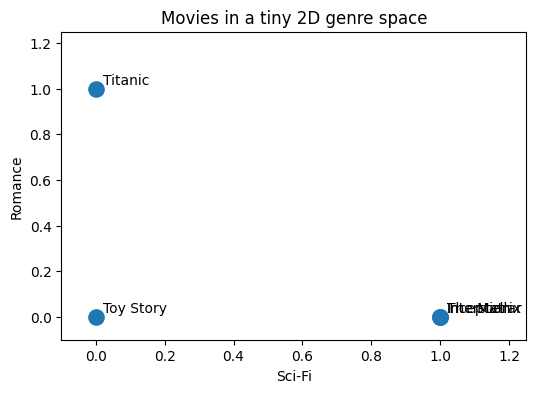

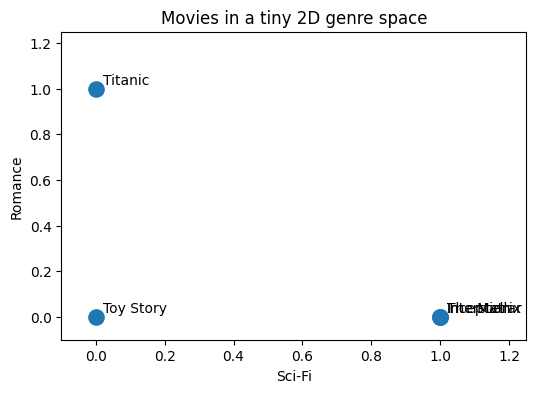

In [8]:
# Teaching note: Plot two selected genre dimensions to make the feature-space idea visible.
plot_df = feature_matrix[["Sci-Fi", "Romance"]].copy()
plot_df["title"] = plot_df.index

ax = plot_df.plot.scatter(x="Sci-Fi", y="Romance", s=120, figsize=(6, 4))
for _, row in plot_df.iterrows():
    ax.text(row["Sci-Fi"] + 0.02, row["Romance"] + 0.02, row["title"])
ax.set_title("Movies in a tiny 2D genre space")
ax.set_xlim(-0.1, 1.25)
ax.set_ylim(-0.1, 1.25)
ax.figure


## What did we learn?

- Feature vectors turn item metadata into numbers.
- One-hot and multi-hot encoding make categorical features usable.
- Cosine, Jaccard, and Euclidean measures answer related but different similarity questions.

## Challenge Lab

1. Add one more movie with at least two genres, a duration, and a rating. Recompute cosine similarity, Jaccard similarity, and Euclidean distance.
2. Change the feature weights so genres count twice as much as numeric features. Which nearest movie changes first?
3. Build a short explanation for one recommendation: name the strongest shared features and the similarity metric you used.
4. Reflection: when would Euclidean distance be less useful than cosine similarity in a real recommender system?
